In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
from lightgbm import LGBMClassifier

In [2]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [3]:
# List contents of the downloaded directory to find the CSV file
print(f"Downloaded dataset path: {path}")
if os.path.isdir(path):
    print("Contents of the downloaded directory:")
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.csv'):
                csv_file_path = os.path.join(root, file)
                print(f"Found CSV file: {csv_file_path}")
                break
        if 'csv_file_path' in locals():
            break
else:
    csv_file_path = path # Assume 'path' is directly the file if it's not a directory

if 'csv_file_path' not in locals():
    # Fallback if no CSV found, assume a common name directly in the downloaded path
    csv_file_path = os.path.join(path, 'creditcard.csv')
    print(f"Attempting to load: {csv_file_path}")

try:
    df = pd.read_csv(csv_file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_file_path}. Please check the dataset structure.")
    print("You might need to adjust the 'csv_file_path' based on the actual downloaded content.")
    df = None # Set df to None to avoid errors in subsequent cells if loading failed

if df is not None:
    display(df.head())

Downloaded dataset path: /kaggle/input/creditcardfraud
Contents of the downloaded directory:
Found CSV file: /kaggle/input/creditcardfraud/creditcard.csv
Dataset loaded successfully.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#### Check for missing values and data types in the dataframe

In [ ]:
# print(df.info())
total = df.isnull().sum().sort_values(ascending = False)
percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False)
pd.concat([total, percent], axis=1, keys=['Total', 'Percent']).transpose()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Total,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Calculate summary statistics of the 'Amount' column

In [ ]:
display(df['Amount'].describe())

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


##### Check the distribution of the 'Class' column to see the fraud ratio

In [ ]:
display(df['Class'].value_counts())

,count
Class,
0,284315
1,492


From the `value_counts()` output, we can observe the imbalance in the `Class` column, where `0` represents non-fraudulent transactions and `1` represents fraudulent transactions. Let's visualize this imbalance.

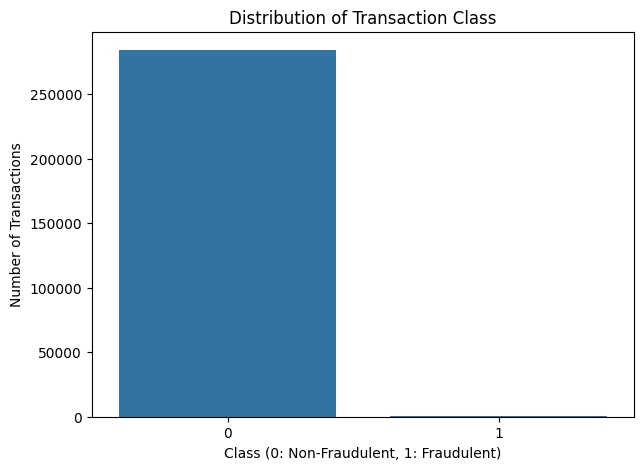

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Transaction Class')
plt.xlabel('Class (0: Non-Fraudulent, 1: Fraudulent)')
plt.ylabel('Number of Transactions')
plt.show()

#### Addressing Class Imbalance

As observed from the distribution plot, the dataset is highly imbalanced, with a much larger number of non-fraudulent transactions (Class 0) compared to fraudulent transactions (Class 1). Training a model directly on this imbalanced dataset can lead to a model that performs poorly on the minority class (fraudulent transactions) because it will be biased towards the majority class.

To mitigate this, we can employ several techniques:
1.  **Undersampling**: Reducing the number of samples from the majority class.
2.  **Oversampling**: Increasing the number of samples from the minority class (e.g., using SMOTE).
3.  **Combination of Undersampling and Oversampling**.
4.  **Using appropriate evaluation metrics**: Beyond accuracy, consider precision, recall, F1-score, and AUC-ROC.
5.  **Using algorithms robust to imbalance**: Such as tree-based models or cost-sensitive learning.

For this analysis, we will start with a simple undersampling approach to balance the dataset. We'll undersample the majority class (non-fraudulent transactions) to match the number of fraudulent transactions.

# Undersampling

In [ ]:
# Separate the classes
df_fraud = df[df['Class'] == 1]
df_non_fraud = df[df['Class'] == 0]

# Undersample the majority class (non-fraudulent transactions)
df_non_fraud_undersampled = df_non_fraud.sample(n=len(df_fraud), random_state=42)

# Concatenate the undersampled non-fraudulent transactions with the fraudulent transactions
df_balanced = pd.concat([df_non_fraud_undersampled, df_fraud], axis=0)

# Shuffle the dataset to mix fraudulent and non-fraudulent transactions
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print('Balanced dataset distribution:')
display(df_balanced['Class'].value_counts())

Balanced dataset distribution:


,count
Class,
1,492
0,492


Now that we have a balanced dataset, let's also visualize its class distribution to confirm the balance.

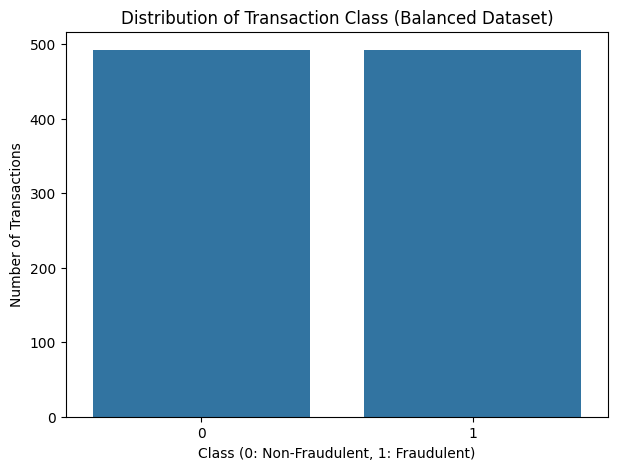

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=df_balanced)
plt.title('Distribution of Transaction Class (Balanced Dataset)')
plt.xlabel('Class (0: Non-Fraudulent, 1: Fraudulent)')
plt.ylabel('Number of Transactions')
plt.show()

#### Data Splitting

Now, we need to split our balanced dataset into features (X) and target (y), and then further divide these into training and testing sets. This is a crucial step to evaluate how well our model generalizes to new, unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_balanced.drop('Class', axis=1)
y = df_balanced['Class']

# Drop 'Time' column as it's not a feature for classification and might lead to data leakage if not handled carefully
X = X.drop('Time', axis=1)

# Split the data into training and testing sets
# We use stratify=y to ensure that the proportion of classes is maintained in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print('\nDistribution of classes in training set:')
display(y_train.value_counts(normalize=True))

print('\nDistribution of classes in test set:')
display(y_test.value_counts(normalize=True))

X_train shape: (787, 29)
X_test shape: (197, 29)
y_train shape: (787,)
y_test shape: (197,)

Distribution of classes in training set:


,proportion
Class,
1,0.500635
0,0.499365



Distribution of classes in test set:


,proportion
Class,
0,0.502538
1,0.497462


#### Verify Feature Scaling for V1-V28

Let's check the range (min/max), mean, and standard deviation of features V1 through V28 in `X_train` to see if they are already scaled as described. This will help us confirm if applying `StandardScaler` again is necessary.

In [ ]:
# Select only the 'V' columns for inspection
v_columns = [col for col in X_train.columns if col.startswith('V')]

print("Current scaling of V1-V28 features in X_train:")
for col in v_columns:
    print(f"\nFeature: {col}")
    print(f"  Min: {X_train[col].min():.4f}")
    print(f"  Max: {X_train[col].max():.4f}")
    print(f"  Mean: {X_train[col].mean():.4f}")
    print(f"  Std: {X_train[col].std():.4f}")

# Also check the 'Amount' column if it's not a 'V' column
if 'Amount' in X_train.columns and 'Amount' not in v_columns:
    print(f"\nFeature: Amount")
    print(f"  Min: {X_train['Amount'].min():.4f}")
    print(f"  Max: {X_train['Amount'].max():.4f}")
    print(f"  Mean: {X_train['Amount'].mean():.4f}")
    print(f"  Std: {X_train['Amount'].std():.4f}")

Current scaling of V1-V28 features in X_train:

Feature: V1
  Min: -30.5524
  Max: 2.3519
  Mean: -2.3398
  Std: 5.5702

Feature: V2
  Min: -8.4022
  Max: 22.0577
  Mean: 1.8624
  Std: 3.6693

Feature: V3
  Min: -31.1037
  Max: 3.1434
  Mean: -3.5513
  Std: 6.2422

Feature: V4
  Min: -3.8537
  Max: 12.1147
  Mean: 2.2677
  Std: 3.2408

Feature: V5
  Min: -22.1055
  Max: 9.8806
  Mean: -1.5750
  Std: 4.1896

Feature: V6
  Min: -6.4063
  Max: 6.4741
  Mean: -0.7194
  Std: 1.6869

Feature: V7
  Min: -43.5572
  Max: 5.8025
  Mean: -2.8271
  Std: 5.8605

Feature: V8
  Min: -41.0443
  Max: 20.0072
  Mean: 0.3317
  Std: 4.6740

Feature: V9
  Min: -13.3202
  Max: 5.2323
  Mean: -1.2712
  Std: 2.3491

Feature: V10
  Min: -24.5883
  Max: 9.3869
  Mean: -2.8386
  Std: 4.5758

Feature: V11
  Min: -2.3825
  Max: 12.0189
  Mean: 1.9018
  Std: 2.7927

Feature: V12
  Min: -18.6837
  Max: 1.7591
  Mean: -3.1775
  Std: 4.6372

Feature: V13
  Min: -3.3039
  Max: 3.0196
  Mean: -0.0533
  Std: 1.0691

Feat

#### Feature Scaling

Many machine learning algorithms perform better when numerical input variables are scaled to a standard range. For this dataset, we'll use `StandardScaler` to transform our features so they have a mean of 0 and a standard deviation of 1. This step is applied to both the training and testing sets to prevent data leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames, retaining column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print('Features scaled successfully.')
display(X_train_scaled.head())

Features scaled successfully.


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.263955,-0.305909,0.806788,-1.072564,0.617535,0.239829,0.666820,-0.146403,1.097250,0.349866,...,-0.329519,-0.159340,0.259514,-0.697567,-0.465642,1.491434,0.307352,-0.394984,-0.601567,-0.418060
1,0.613693,-0.608143,0.837212,-0.330861,0.062637,0.605688,0.328217,-0.014711,1.132920,0.519352,...,-0.329458,-0.095703,0.680747,-0.051460,1.324050,0.576384,1.217630,-0.028078,-0.023153,-0.443949
2,-2.421436,1.885359,-3.086374,2.963276,-1.795410,-0.989119,-2.344862,0.132009,-2.146664,-2.241522,...,0.790572,-1.008169,0.909919,1.064708,-1.696014,-0.212334,1.378475,1.972697,-3.396976,-0.462126
3,0.555819,0.141097,-0.254235,0.478808,0.386488,-0.335777,0.181064,0.090982,-0.210644,-0.092808,...,0.177853,0.020410,0.121455,0.155937,0.769137,-0.717293,-0.581712,0.208107,-0.184775,-0.457118
4,0.142091,-0.014650,0.416436,-0.016854,-0.105258,-0.115121,0.080440,0.185278,-0.173436,-0.153085,...,0.198641,0.191889,0.679494,0.049467,0.681562,-0.753837,-0.613966,0.517554,0.848552,-0.081863


#### Model Training: LightGBM Classifier

We will now train a Light Gradient Boosting Machine (LightGBM) Classifier. LightGBM is a high-performance, open-source gradient boosting framework that uses tree-based learning algorithms. It's known for its speed and efficiency, making it suitable for large datasets. We'll train the model on our scaled training data (`X_train_scaled`, `y_train`).

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize the LightGBM Classifier
lgbm_clf = LGBMClassifier(random_state=42)

# Train the model
print("Training LightGBM Classifier...")
lgbm_clf.fit(X_train_scaled, y_train)
print("LightGBM Classifier trained successfully.")

Training LightGBM Classifier...
[LightGBM] [Info] Number of positive: 394, number of negative: 393
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000456 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 787, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500635 -> initscore=0.002541
[LightGBM] [Info] Start training from score 0.002541
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Classifier trained successfully.


#### Model Evaluation

After training the model, it's crucial to evaluate its performance on the unseen test data (`X_test_scaled`, `y_test`). For a highly imbalanced classification task like fraud detection, accuracy alone is not a sufficient metric. We'll use a range of metrics including precision, recall, F1-score, and ROC AUC score, which provide a more comprehensive understanding of the model's effectiveness, especially in identifying the minority class (fraudulent transactions).

In [ ]:
# Make predictions on the scaled test data
y_pred = lgbm_clf.predict(X_test_scaled)
y_pred_proba = lgbm_clf.predict_proba(X_test_scaled)[:, 1] # Probability of the positive class (fraud)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Model Performance on Test Set:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  ROC AUC Score: {roc_auc:.4f}")

Model Performance on Test Set:
  Accuracy: 0.9340
  Precision: 0.9381
  Recall: 0.9286
  F1-Score: 0.9333
  ROC AUC Score: 0.9863


#### Visualization of LightGBM Model Performance

To further analyze the `LGBMClassifier`'s performance, we'll visualize its **Confusion Matrix**, **Feature Importance**, and the **Receiver Operating Characteristic (ROC) Curve**.

##### Confusion Matrix

The confusion matrix provides a clear picture of true positives, true negatives, false positives, and false negatives. This is particularly important in fraud detection where misclassifying a fraudulent transaction (false negative) can be very costly.

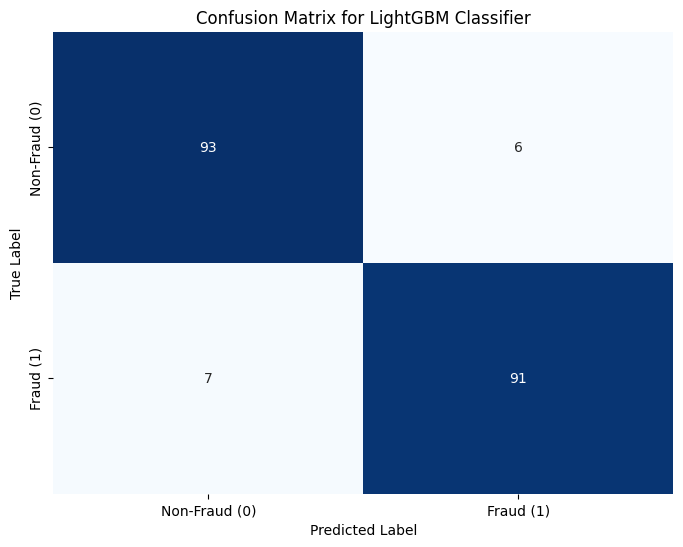

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LightGBM Classifier')
plt.show()

##### Feature Importance

Understanding feature importance helps us identify which features the model considers most significant in making its predictions. This can offer insights into the underlying patterns of fraudulent activities.

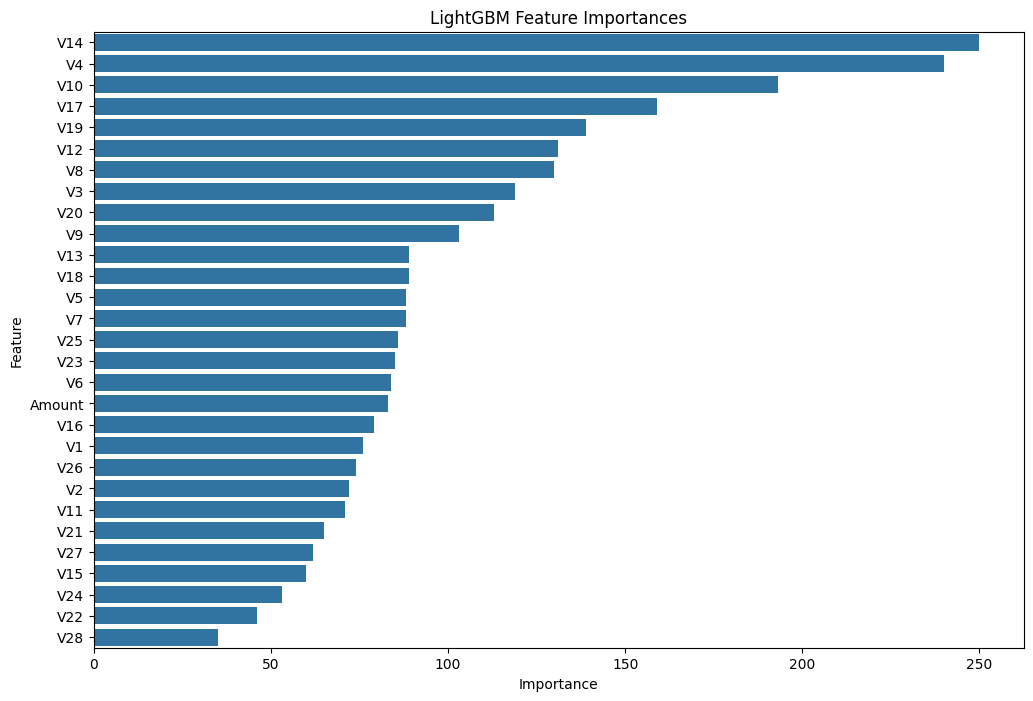

In [ ]:
# Get feature importances from the LGBM model
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm_clf.feature_importances_
}).sort_values(by='importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title('LightGBM Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

##### Area Under the Receiver Operating Characteristic Curve (AUC-ROC)

The ROC curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The AUC (Area Under the Curve) provides an aggregate measure of performance across all possible classification thresholds. A higher AUC indicates a better model.

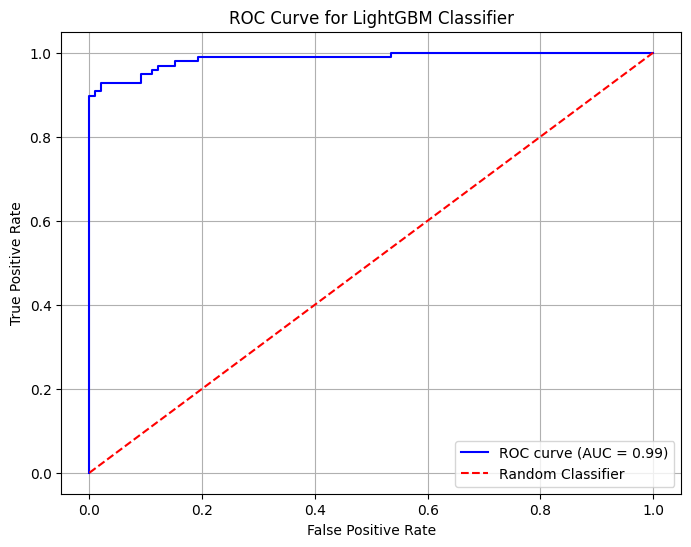

In [ ]:
from sklearn.metrics import roc_curve

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LightGBM Classifier')
plt.legend()
plt.grid(True)
plt.show()

# Oversampling


## SMOTE (Synthetic Minority Over-sampling Technique)
`SMOTE: Synthetic Minority Over-sampling Technique by Nitesh V. Chawla et. al, Journal of Artificial Intelligence Research (2002)`

Instead of undersampling the majority class, SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic samples for the minority class. This helps to increase the number of minority class samples, balancing the dataset without discarding potentially useful information from the majority class. We will apply SMOTE to the training data of the *original* imbalanced dataset after splitting, ensuring that the test set remains untouched for a realistic evaluation.

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Prepare Original Imbalanced Data ---
# Re-define features (X_original) and target (y_original) from the original full dataframe (df)
X_original = df.drop(['Class', 'Time'], axis=1)
y_original = df['Class']

print(f"Original imbalanced dataset shape: X={X_original.shape}, y={y_original.shape}")
print("Original class distribution:")
display(y_original.value_counts())

# --- 2. Split Original Data into Training and Test Sets ---
# Crucially, we split BEFORE applying SMOTE to prevent data leakage from test set
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X_original, y_original, test_size=0.2, random_state=42, stratify=y_original)

print(f"\nShape after splitting original data:")
print(f"X_train_original: {X_train_original.shape}, y_train_original: {y_train_original.shape}")
print(f"X_test_original: {X_test_original.shape}, y_test_original: {y_test_original.shape}")

# --- 3. Scale the Training and Test Data ---
scaler_smote = StandardScaler()
X_train_original_scaled = scaler_smote.fit_transform(X_train_original)
X_test_original_scaled = scaler_smote.transform(X_test_original)

# Convert back to DataFrame to retain column names for consistency
X_train_original_scaled = pd.DataFrame(X_train_original_scaled, columns=X_original.columns)
X_test_original_scaled = pd.DataFrame(X_test_original_scaled, columns=X_original.columns)

print("\nFeatures scaled successfully on original split data.")

Original imbalanced dataset shape: X=(284807, 29), y=(284807,)
Original class distribution:


,count
Class,
0,284315
1,492



Shape after splitting original data:
X_train_original: (227845, 29), y_train_original: (227845,)
X_test_original: (56962, 29), y_test_original: (56962,)

Features scaled successfully on original split data.


##### Apply SMOTE to the Training Data

Now, we'll apply SMOTE *only* to the training data to balance the classes. This ensures that our test set remains representative of the real-world imbalanced distribution, allowing for a more accurate evaluation of the model's generalization ability.

In [ ]:
# Initialize SMOTE
sm = SMOTE(random_state=42)

# Apply SMOTE to the scaled training data
X_train_smote, y_train_smote = sm.fit_resample(X_train_original_scaled, y_train_original)

print(f"\nShape after SMOTE on training data: X_train_smote={X_train_smote.shape}, y_train_smote={y_train_smote.shape}")
print("Class distribution after SMOTE:")
display(y_train_smote.value_counts())


Shape after SMOTE on training data: X_train_smote=(454902, 29), y_train_smote=(454902,)
Class distribution after SMOTE:


,count
Class,
0,227451
1,227451


#### Model Training and Evaluation with SMOTE Data (LightGBM)

With our training data balanced using SMOTE and scaled, we can now train a new `LGBMClassifier` and evaluate its performance using the same metrics as before (accuracy, precision, recall, F1-score, and ROC AUC).

In [ ]:
# Initialize the LightGBM Classifier for SMOTE data
lgbm_clf_smote = LGBMClassifier(random_state=42)

# Train the model on SMOTE-resampled training data
print("Training LightGBM Classifier with SMOTE data...")
lgbm_clf_smote.fit(X_train_smote, y_train_smote)
print("LightGBM Classifier with SMOTE data trained successfully.")

# Make predictions on the scaled original test data
y_pred_smote = lgbm_clf_smote.predict(X_test_original_scaled)
y_pred_proba_smote = lgbm_clf_smote.predict_proba(X_test_original_scaled)[:, 1] # Probability of the positive class (fraud)

# Calculate evaluation metrics
accuracy_smote = accuracy_score(y_test_original, y_pred_smote)
precision_smote = precision_score(y_test_original, y_pred_smote)
recall_smote = recall_score(y_test_original, y_pred_smote)
f1_smote = f1_score(y_test_original, y_pred_smote)
roc_auc_smote = roc_auc_score(y_test_original, y_pred_proba_smote)

print(f"\nModel Performance on Original Test Set (LGBM with SMOTE Training):")
print(f"  Accuracy: {accuracy_smote:.4f}")
print(f"  Precision: {precision_smote:.4f}")
print(f"  Recall: {recall_smote:.4f}")
print(f"  F1-Score: {f1_smote:.4f}")
print(f"  ROC AUC Score: {roc_auc_smote:.4f}")

Training LightGBM Classifier with SMOTE data...
[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.255227 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Classifier with SMOTE data trained successfully.

Model Performance on Original Test Set (LGBM with SMOTE Training):
  Accuracy: 0.9980
  Precision: 0.4574
  Recall: 0.8776
  F1-Score: 0.6014
  ROC AUC Score: 0.9539


#### Visualization of LightGBM Model Performance with SMOTE Data

Now let's visualize the performance of the `LGBMClassifier` trained on SMOTE-resampled data. We'll generate a Confusion Matrix, Feature Importance plot, and an ROC Curve, similar to what we did for the undersampled model, but this time using the predictions from the SMOTE-trained model on the original (unseen) test set.

##### Confusion Matrix (LGBM with SMOTE)

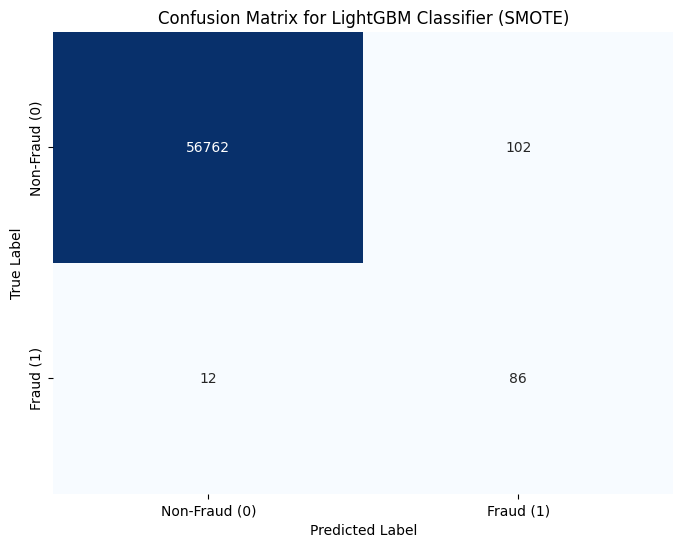

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the SMOTE model
cm_smote = confusion_matrix(y_test_original, y_pred_smote)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LightGBM Classifier (SMOTE)')
plt.show()

##### Feature Importance (LGBM with SMOTE)

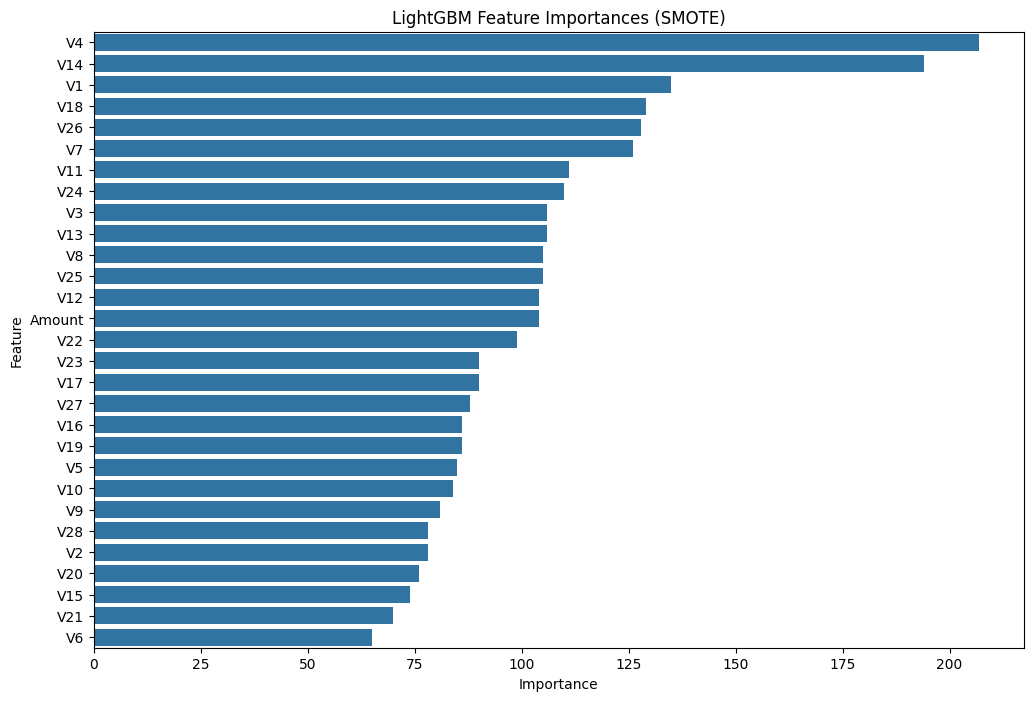

In [ ]:
# Get feature importances from the LGBM model trained with SMOTE
feature_importances_smote = pd.DataFrame({
    'feature': X_original.columns, # Use original column names for features
    'importance': lgbm_clf_smote.feature_importances_
}).sort_values(by='importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_smote)
plt.title('LightGBM Feature Importances (SMOTE)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

##### Area Under the Receiver Operating Characteristic Curve (AUC-ROC) (LGBM with SMOTE)

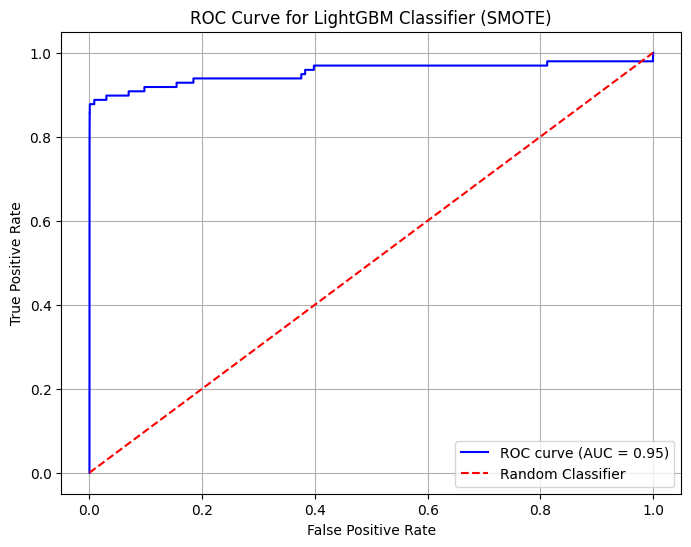

In [ ]:
from sklearn.metrics import roc_curve

# Calculate ROC curve points for the SMOTE model
fpr_smote, tpr_smote, thresholds_smote = roc_curve(y_test_original, y_pred_proba_smote)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_smote, tpr_smote, color='blue', label=f'ROC curve (AUC = {roc_auc_smote:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LightGBM Classifier (SMOTE)')
plt.legend()
plt.grid(True)
plt.show()

# Combination of Undersampling and Oversampling

### Key Combined Sampling Techniques
#### SMOTE-Tomek Links:
Uses SMOTE (Synthetic Minority Over-sampling Technique) to increase minority instances, then uses Tomek Links to remove pairs of instances from opposite classes that are closest to each other, increasing the separation between classes.

#### SMOTE-ENN (Edited Nearest Neighbors):
Similar to SMOTE-Tomek, but more aggressive in removing majority class instances. It removes any example from either class that differs from its
-nearest neighbors, effectively cleaning up noisy boundaries.
`SMOTE vs. SMOTEENN: A Study on the Performance of Resampling Algorithms for Addressing Class Imbalance in Regression Models by Gazi Husain et. al, Algoritnms 2025`

#### Random Oversampling and Undersampling:
A simpler approach where a modest amount of random oversampling is applied to the minority class, followed by random undersampling on the majority class.

The 'Combination of Undersampling and Oversampling' technique is a hybrid approach to handle imbalanced datasets, like the fraud detection one we're working with. Imagine you have a dataset where one class (e.g., non-fraudulent transactions) is much, much larger than the other (fraudulent transactions).

Here's how the combination approach works in simple terms:

1. You have too many 'normal' cases (majority class) and too few 'fraud' cases (minority class). If you train a model on this, it'll mostly learn about 'normal' cases and might miss many 'fraud' cases because they're rare.

2. Instead of just undersampling (throwing away normal cases) or just oversampling (creating fake fraud cases), you do both.

##### Partial Undersampling:
You first reduce the number of the 'normal' cases, but not so much that you lose too much valuable information. You still keep a good chunk of them.

##### Oversampling (like SMOTE):
Then, you create synthetic examples of the 'fraud' cases. This helps the model see more examples of what 'fraud' looks like without simply duplicating existing ones.

3. The Goal:
By doing this, you bring the number of 'normal' and 'fraud' cases closer together. This allows your machine learning model to learn more effectively from both classes, leading to better detection of the rare 'fraud' events without discarding too much real-world data from the 'normal' class. It aims to strike a balance between losing information (undersampling) and potentially overfitting to synthetic data (oversampling).

### Combination of Undersampling and Oversampling: SMOTE-ENN

We will now use a combined sampling technique called SMOTE-ENN (SMOTE followed by Edited Nearest Neighbors). This approach first oversamples the minority class using SMOTE and then cleans up the resulting dataset by removing noisy or ambiguous samples using Edited Nearest Neighbors. This can lead to better class separation and potentially improved model performance compared to using SMOTE or undersampling alone.

We will apply SMOTE-ENN to the training data of the *original* imbalanced dataset after splitting, and then train and evaluate a new `LGBMClassifier`.

In [ ]:
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Prepare Original Imbalanced Data (if not already prepared) ---
# Re-define features (X_original) and target (y_original) from the original full dataframe (df)
# This step ensures we are working with the clean, original dataset before any balancing techniques.
if 'X_original' not in locals() or 'y_original' not in locals():
    X_original = df.drop(['Class', 'Time'], axis=1)
    y_original = df['Class']

print(f"Original imbalanced dataset shape: X={X_original.shape}, y={y_original.shape}")
print("Original class distribution:")
display(y_original.value_counts())

# --- 2. Split Original Data into Training and Test Sets ---
X_train_orig_smenn, X_test_orig_smenn, y_train_orig_smenn, y_test_orig_smenn = train_test_split(X_original, y_original, test_size=0.2, random_state=42, stratify=y_original)

print(f"\nShape after splitting original data:")
print(f"X_train_original: {X_train_orig_smenn.shape}, y_train_original: {y_train_orig_smenn.shape}")
print(f"X_test_original: {X_test_orig_smenn.shape}, y_test_original: {y_test_orig_smenn.shape}")

# --- 3. Scale the Training and Test Data ---
scaler_smenn = StandardScaler()
X_train_orig_smenn_scaled = scaler_smenn.fit_transform(X_train_orig_smenn)
X_test_orig_smenn_scaled = scaler_smenn.transform(X_test_orig_smenn)

# Convert back to DataFrame to retain column names for consistency
X_train_orig_smenn_scaled = pd.DataFrame(X_train_orig_smenn_scaled, columns=X_original.columns)
X_test_orig_smenn_scaled = pd.DataFrame(X_test_orig_smenn_scaled, columns=X_original.columns)

print("\nFeatures scaled successfully on original split data.")

Original imbalanced dataset shape: X=(284807, 29), y=(284807,)
Original class distribution:


,count
Class,
0,284315
1,492



Shape after splitting original data:
X_train_original: (227845, 29), y_train_original: (227845,)
X_test_original: (56962, 29), y_test_original: (56962,)

Features scaled successfully on original split data.


##### Apply SMOTE-ENN to the Training Data

Now, we'll apply SMOTE-ENN *only* to the training data to balance the classes. This ensures our test set remains untouched for realistic evaluation.

In [ ]:
# Initialize SMOTE-ENN
sme = SMOTEENN(random_state=42)

# Apply SMOTE-ENN to the scaled training data
X_train_smenn, y_train_smenn = sme.fit_resample(X_train_orig_smenn_scaled,
                                                y_train_orig_smenn)

print(f"\nShape after SMOTE-ENN on training data: X_train_smenn={X_train_smenn.shape}, y_train_smenn={y_train_smenn.shape}")
print("Class distribution after SMOTE-ENN:")
display(y_train_smenn.value_counts())


Shape after SMOTE-ENN on training data: X_train_smenn=(454517, 29), y_train_smenn=(454517,)
Class distribution after SMOTE-ENN:


,count
Class,
1,227451
0,227066


#### Model Training and Evaluation with SMOTE-ENN Data (LightGBM)

With our training data balanced using SMOTE-ENN and scaled, we can now train a new `LGBMClassifier` and evaluate its performance.

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize the LightGBM Classifier for SMOTE-ENN data
lgbm_clf_smenn = LGBMClassifier(random_state=42)

# Train the model on SMOTE-ENN-resampled training data
print("Training LightGBM Classifier with SMOTE-ENN data...")
lgbm_clf_smenn.fit(X_train_smenn, y_train_smenn)
print("LightGBM Classifier with SMOTE-ENN data trained successfully.")

# Make predictions on the scaled original test data
y_pred_smenn = lgbm_clf_smenn.predict(X_test_orig_smenn_scaled)
y_pred_proba_smenn = lgbm_clf_smenn.predict_proba(X_test_orig_smenn_scaled)[:, 1] # Probability of the positive class (fraud)

# Calculate evaluation metrics
accuracy_smenn = accuracy_score(y_test_orig_smenn, y_pred_smenn)
precision_smenn = precision_score(y_test_orig_smenn, y_pred_smenn)
recall_smenn = recall_score(y_test_orig_smenn, y_pred_smenn)
f1_smenn = f1_score(y_test_orig_smenn, y_pred_smenn)
roc_auc_smenn = roc_auc_score(y_test_orig_smenn, y_pred_proba_smenn)

print(f"\nModel Performance on Original Test Set (LGBM with SMOTE-ENN Training):")
print(f"  Accuracy: {accuracy_smenn:.4f}")
print(f"  Precision: {precision_smenn:.4f}")
print(f"  Recall: {recall_smenn:.4f}")
print(f"  F1-Score: {f1_smenn:.4f}")
print(f"  ROC AUC Score: {roc_auc_smenn:.4f}")

Training LightGBM Classifier with SMOTE-ENN data...
[LightGBM] [Info] Number of positive: 227451, number of negative: 227066
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.142292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 454517, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500424 -> initscore=0.001694
[LightGBM] [Info] Start training from score 0.001694
LightGBM Classifier with SMOTE-ENN data trained successfully.

Model Performance on Original Test Set (LGBM with SMOTE-ENN Training):
  Accuracy: 0.9979
  Precision: 0.4416
  Recall: 0.8878
  F1-Score: 0.5898
  ROC AUC Score: 0.9707


#### Visualization of LightGBM Model Performance with SMOTE-ENN Data

Let's visualize the performance of the `LGBMClassifier` trained on SMOTE-ENN resampled data. We'll generate a Confusion Matrix, Feature Importance plot, and an ROC Curve, using the predictions from the SMOTE-ENN trained model on the original (unseen) test set.

##### Confusion Matrix (LGBM with SMOTE-ENN)

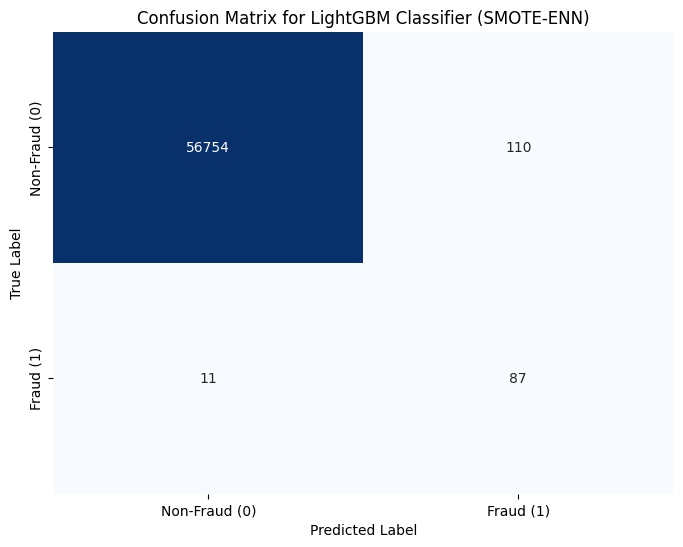

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the SMOTE-ENN model
cm_smenn = confusion_matrix(y_test_orig_smenn, y_pred_smenn)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_smenn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LightGBM Classifier (SMOTE-ENN)')
plt.show()

##### Feature Importance (LGBM with SMOTE-ENN)

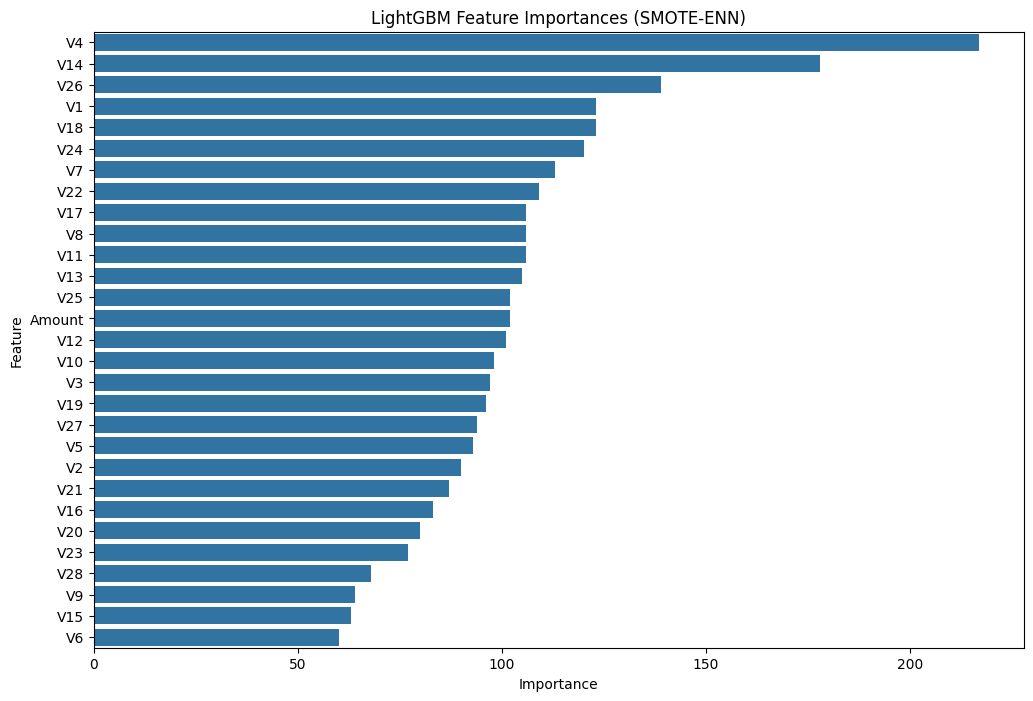

In [ ]:
# Get feature importances from the LGBM model trained with SMOTE-ENN
feature_importances_smenn = pd.DataFrame({
    'feature': X_original.columns, # Use original column names for features
    'importance': lgbm_clf_smenn.feature_importances_
}).sort_values(by='importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_smenn)
plt.title('LightGBM Feature Importances (SMOTE-ENN)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

##### Area Under the Receiver Operating Characteristic Curve (AUC-ROC) (LGBM with SMOTE-ENN)

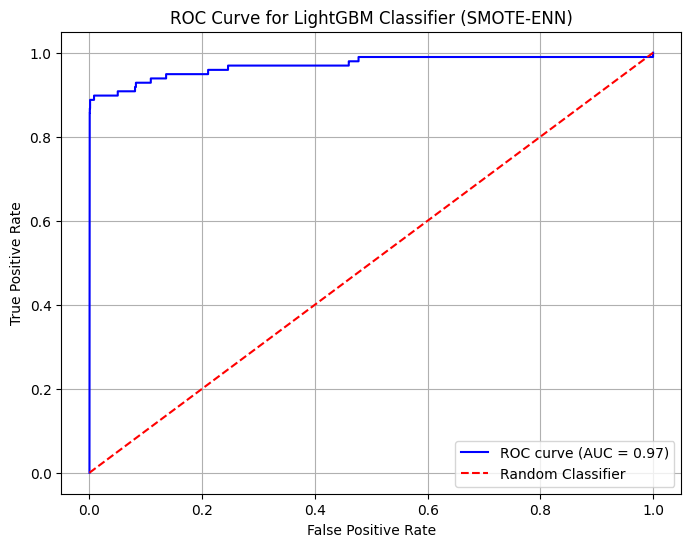

In [ ]:
from sklearn.metrics import roc_curve

# Calculate ROC curve points for the SMOTE-ENN model
fpr_smenn, tpr_smenn, thresholds_smenn = roc_curve(y_test_orig_smenn, y_pred_proba_smenn)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_smenn, tpr_smenn, color='blue', label=f'ROC curve (AUC = {roc_auc_smenn:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LightGBM Classifier (SMOTE-ENN)')
plt.legend()
plt.grid(True)
plt.show()

### Combination of Random Oversampling and Undersampling

This is a simpler, yet often effective, hybrid approach to handle class imbalance. It involves two steps:

1.  **Random Oversampling**: Randomly duplicate samples from the minority class. This increases the number of minority class instances.
2.  **Random Undersampling**: Randomly remove samples from the majority class. This reduces the number of majority class instances.

The goal is to achieve a more balanced class distribution, which can help the model learn more effectively from the minority class without introducing the complexities of synthetic sample generation (like SMOTE) or cleaning procedures (like ENN or Tomek Links).

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- 1. Prepare Original Imbalanced Data (if not already prepared) ---
# Re-define features (X_original) and target (y_original) from the original full dataframe (df)
# This step ensures we are working with the clean, original dataset before any balancing techniques.
if 'X_original' not in locals() or 'y_original' not in locals():
    X_original = df.drop(['Class', 'Time'], axis=1)
    y_original = df['Class']

print(f"Original imbalanced dataset shape: X={X_original.shape}, y={y_original.shape}")
print("Original class distribution:")
display(y_original.value_counts())

# --- 2. Split Original Data into Training and Test Sets ---
X_train_orig_rand, X_test_orig_rand, y_train_orig_rand, y_test_orig_rand = train_test_split(X_original, y_original, test_size=0.2, random_state=42, stratify=y_original)

print(f"\nShape after splitting original data:")
print(f"X_train_original: {X_train_orig_rand.shape}, y_train_original: {y_train_orig_rand.shape}")
print(f"X_test_original: {X_test_orig_rand.shape}, y_test_original: {y_test_orig_rand.shape}")

# --- 3. Scale the Training and Test Data ---
scaler_rand = StandardScaler()
X_train_orig_rand_scaled = scaler_rand.fit_transform(X_train_orig_rand)
X_test_orig_rand_scaled = scaler_rand.transform(X_test_orig_rand)

# Convert back to DataFrame to retain column names for consistency
X_train_orig_rand_scaled = pd.DataFrame(X_train_orig_rand_scaled, columns=X_original.columns)
X_test_orig_rand_scaled = pd.DataFrame(X_test_orig_rand_scaled, columns=X_original.columns)

print("\nFeatures scaled successfully on original split data.")

Original imbalanced dataset shape: X=(284807, 29), y=(284807,)
Original class distribution:


,count
Class,
0,284315
1,492



Shape after splitting original data:
X_train_original: (227845, 29), y_train_original: (227845,)
X_test_original: (56962, 29), y_test_original: (56962,)

Features scaled successfully on original split data.


##### Apply Random Oversampling and Undersampling to the Training Data

Now, we'll apply `RandomOverSampler` followed by `RandomUnderSampler` to the training data. This will create a balanced training set while keeping the test set pristine for objective evaluation.

In [ ]:
# Initialize RandomOverSampler and RandomUnderSampler
os = RandomOverSampler(random_state=42)
us = RandomUnderSampler(random_state=42)

# Create a pipeline for oversampling and undersampling
# This ensures the oversampling is applied first, then undersampling on the result
pipeline = Pipeline([('oversample', os), ('undersample', us)])

# Apply the pipeline to the scaled training data
X_train_rand, y_train_rand = pipeline.fit_resample(X_train_orig_rand_scaled, y_train_orig_rand)

print(f"\nShape after Random Oversampling and Undersampling on training data: X_train_rand={X_train_rand.shape}, y_train_rand={y_train_rand.shape}")
print("Class distribution after Random Oversampling and Undersampling:")
display(y_train_rand.value_counts())


Shape after Random Oversampling and Undersampling on training data: X_train_rand=(454902, 29), y_train_rand=(454902,)
Class distribution after Random Oversampling and Undersampling:


,count
Class,
0,227451
1,227451


#### Model Training and Evaluation with Random Oversampling/Undersampling Data (LightGBM)

With our training data balanced using a combination of random oversampling and undersampling, we can now train a new `LGBMClassifier` and evaluate its performance.

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize the LightGBM Classifier for randomly sampled data
lgbm_clf_rand = LGBMClassifier(random_state=42)

# Train the model on randomly resampled training data
print("Training LightGBM Classifier with Random Oversampling/Undersampling data...")
lgbm_clf_rand.fit(X_train_rand, y_train_rand)
print("LightGBM Classifier with Random Oversampling/Undersampling data trained successfully.")

# Make predictions on the scaled original test data
y_pred_rand = lgbm_clf_rand.predict(X_test_orig_rand_scaled)
y_pred_proba_rand = lgbm_clf_rand.predict_proba(X_test_orig_rand_scaled)[:, 1] # Probability of the positive class (fraud)

# Calculate evaluation metrics
accuracy_rand = accuracy_score(y_test_orig_rand, y_pred_rand)
precision_rand = precision_score(y_test_orig_rand, y_pred_rand)
recall_rand = recall_score(y_test_orig_rand, y_pred_rand)
f1_rand = f1_score(y_test_orig_rand, y_pred_rand)
roc_auc_rand = roc_auc_score(y_test_orig_rand, y_pred_proba_rand)

print(f"\nModel Performance on Original Test Set (LGBM with Random Sampling Training):")
print(f"  Accuracy: {accuracy_rand:.4f}")
print(f"  Precision: {precision_rand:.4f}")
print(f"  Recall: {recall_rand:.4f}")
print(f"  F1-Score: {f1_rand:.4f}")
print(f"  ROC AUC Score: {roc_auc_rand:.4f}")

Training LightGBM Classifier with Random Oversampling/Undersampling data...
[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.146997 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7391
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Classifier with Random Oversampling/Undersampling data trained successfully.

Model Performance on Original Test Set (LGBM with Random Sampling Training):
  Accuracy: 0.9993
  Precision: 0.7900
  Recall: 0.8061
  F1-Score: 0.7980
  ROC AUC Score: 0.9631


#### Visualization of LightGBM Model Performance with Random Oversampling/Undersampling Data

Let's visualize the performance of the `LGBMClassifier` trained on randomly oversampled/undersampled data. We'll generate a Confusion Matrix, Feature Importance plot, and an ROC Curve, using the predictions from this trained model on the original (unseen) test set.

##### Confusion Matrix (LGBM with Random Oversampling/Undersampling)

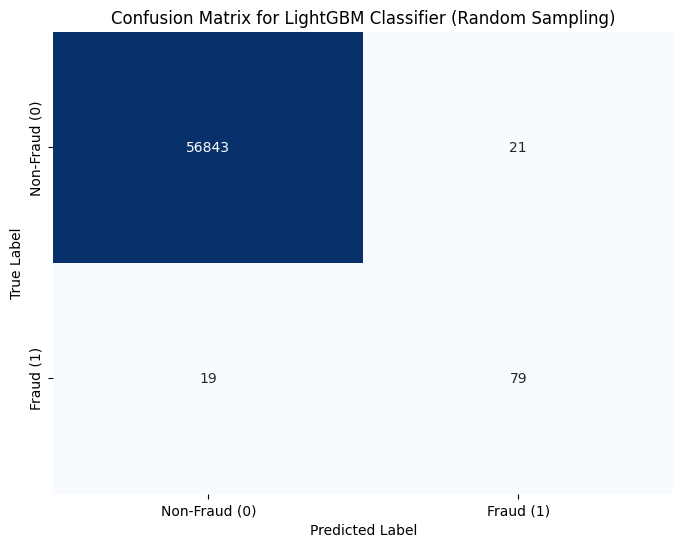

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the random sampling model
cm_rand = confusion_matrix(y_test_orig_rand, y_pred_rand)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rand, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LightGBM Classifier (Random Sampling)')
plt.show()

##### Feature Importance (LGBM with Random Oversampling/Undersampling)

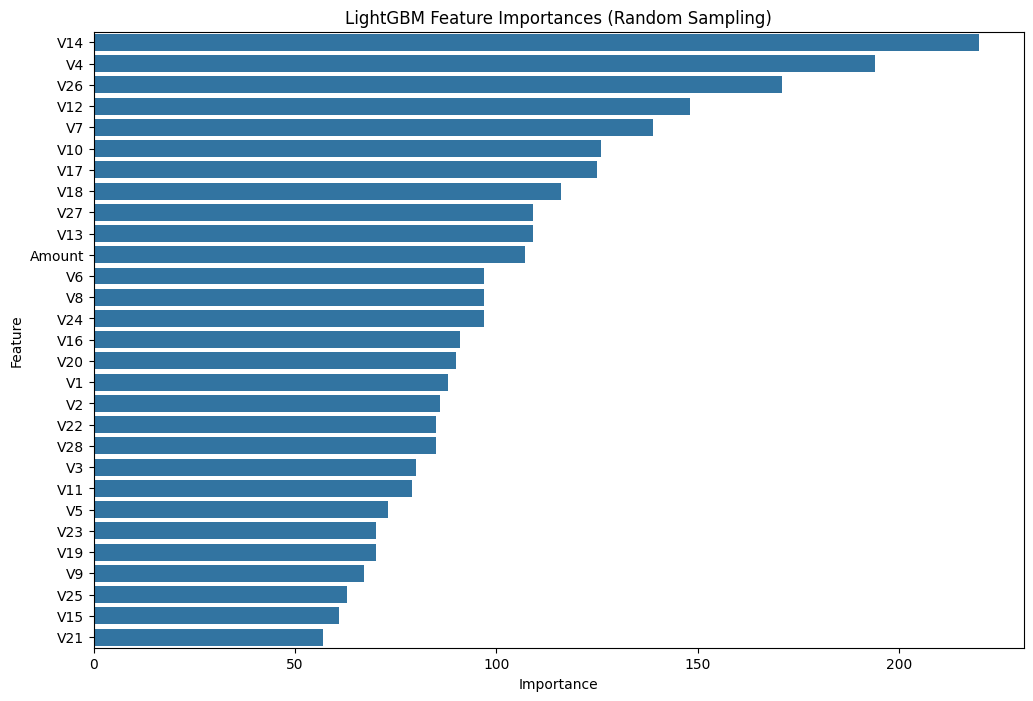

In [ ]:
# Get feature importances from the LGBM model trained with random sampling
feature_importances_rand = pd.DataFrame({
    'feature': X_original.columns, # Use original column names for features
    'importance': lgbm_clf_rand.feature_importances_
}).sort_values(by='importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_rand)
plt.title('LightGBM Feature Importances (Random Sampling)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

##### Area Under the Receiver Operating Characteristic Curve (AUC-ROC) (LGBM with Random Oversampling/Undersampling)

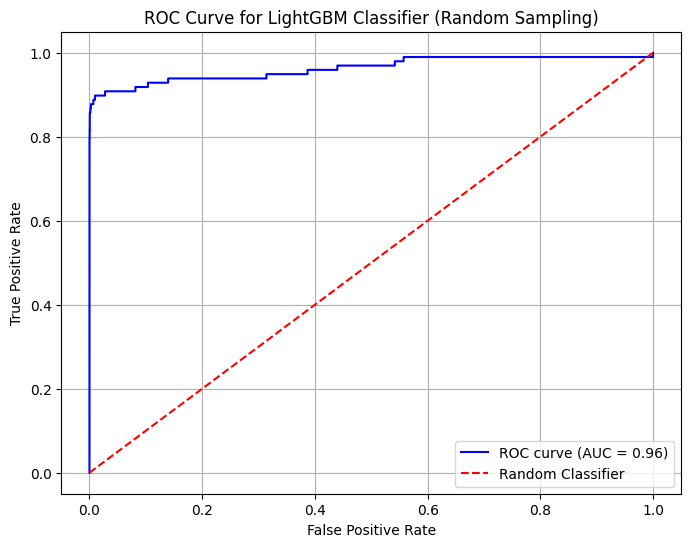

In [ ]:
from sklearn.metrics import roc_curve

# Calculate ROC curve points for the random sampling model
fpr_rand, tpr_rand, thresholds_rand = roc_curve(y_test_orig_rand, y_pred_proba_rand)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rand, tpr_rand, color='blue', label=f'ROC curve (AUC = {roc_auc_rand:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LightGBM Classifier (Random Sampling)')
plt.legend()
plt.grid(True)
plt.show()

### Combination of Undersampling and Oversampling (SMOTE-Tomek Links)
`Original SMOTE Paper: Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. Journal of Artificial Intelligence Research`

`Tomek Links: Tomek, I. (1976). Two modifications of CNN (condensed nearest neighbor). IEEE Transactions on Systems, Man, and Cybernetics`

SMOTE-Tomek Links is another hybrid sampling technique that aims to balance a dataset while also cleaning up the class boundaries. It works in two main steps:

1.  **SMOTE (Synthetic Minority Over-sampling Technique)**: First, SMOTE is applied to the minority class. This generates synthetic samples for the minority class, increasing its representation in the dataset. As explained before, these synthetic samples are created by interpolating between existing minority class instances and their nearest neighbors.
2.  **Tomek Links**: After SMOTE, Tomek Links are identified and removed. A Tomek Link is defined as a pair of samples from different classes that are each other's nearest neighbors. Removing these links helps to clean the data by eliminating noisy or ambiguous samples that lie close to the decision boundary. Typically, the majority class sample in a Tomek Link is removed, which helps to increase the separation between the classes and make the decision boundary clearer for the classifier.

This combination helps to address both the class imbalance problem and the issue of overlapping class regions, potentially leading to a more robust model.

#### Model Training and Evaluation with SMOTE-Tomek Data (LightGBM)

With our training data balanced using SMOTE-Tomek and scaled, we can now train a new `LGBMClassifier` and evaluate its performance.

In [4]:
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Prepare Original Imbalanced Data (if not already prepared) ---
# Re-define features (X_original) and target (y_original) from the original full dataframe (df)
# This step ensures we are working with the clean, original dataset before any balancing techniques.
if 'X_original' not in locals() or 'y_original' not in locals():
    X_original = df.drop(['Class', 'Time'], axis=1)
    y_original = df['Class']

print(f"Original imbalanced dataset shape: X={X_original.shape}, y={y_original.shape}")
print("Original class distribution:")
display(y_original.value_counts())

# --- 2. Split Original Data into Training and Test Sets ---
X_train_orig_smtom, X_test_orig_smtom, y_train_orig_smtom, y_test_orig_smtom = train_test_split(X_original, y_original, test_size=0.2, random_state=42, stratify=y_original)

print(f"\nShape after splitting original data:")
print(f"X_train_original: {X_train_orig_smtom.shape}, y_train_original: {y_train_orig_smtom.shape}")
print(f"X_test_original: {X_test_orig_smtom.shape}, y_test_original: {y_test_orig_smtom.shape}")

# --- 3. Scale the Training and Test Data ---
scaler_smtom = StandardScaler()
X_train_orig_smtom_scaled = scaler_smtom.fit_transform(X_train_orig_smtom)
X_test_orig_smtom_scaled = scaler_smtom.transform(X_test_orig_smtom)

# Convert back to DataFrame to retain column names for consistency
X_train_orig_smtom_scaled = pd.DataFrame(X_train_orig_smtom_scaled, columns=X_original.columns)
X_test_orig_smtom_scaled = pd.DataFrame(X_test_orig_smtom_scaled, columns=X_original.columns)

print("\nFeatures scaled successfully on original split data.")

Original imbalanced dataset shape: X=(284807, 29), y=(284807,)
Original class distribution:


,count
Class,
0,284315
1,492



Shape after splitting original data:
X_train_original: (227845, 29), y_train_original: (227845,)
X_test_original: (56962, 29), y_test_original: (56962,)

Features scaled successfully on original split data.


In [6]:
from imblearn.combine import SMOTETomek
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- Apply SMOTE-Tomek to the Training Data ---
# Initialize SMOTETomek
smtom = SMOTETomek(random_state=42)

# Apply SMOTE-Tomek to the scaled training data
X_train_smtom, y_train_smtom = smtom.fit_resample(X_train_orig_smtom_scaled,
                                                y_train_orig_smtom)

print(f"\nShape after SMOTE-Tomek on training data: X_train_smtom={X_train_smtom.shape}, y_train_smtom={y_train_smtom.shape}")
print("Class distribution after SMOTE-Tomek:")
display(y_train_smtom.value_counts())

# Initialize the LightGBM Classifier for SMOTE-Tomek data
lgbm_clf_smtom = LGBMClassifier(random_state=42)

# Train the model on SMOTE-Tomek-resampled training data
print("Training LightGBM Classifier with SMOTE-Tomek data...")
lgbm_clf_smtom.fit(X_train_smtom, y_train_smtom)
print("LightGBM Classifier with SMOTE-Tomek data trained successfully.")

# Make predictions on the scaled original test data
y_pred_smtom = lgbm_clf_smtom.predict(X_test_orig_smtom_scaled)
y_pred_proba_smtom = lgbm_clf_smtom.predict_proba(X_test_orig_smtom_scaled)[:, 1] # Probability of the positive class (fraud)

# Calculate evaluation metrics
accuracy_smtom = accuracy_score(y_test_orig_smtom, y_pred_smtom)
precision_smtom = precision_score(y_test_orig_smtom, y_pred_smtom)
recall_smtom = recall_score(y_test_orig_smtom, y_pred_smtom)
f1_smtom = f1_score(y_test_orig_smtom, y_pred_smtom)
roc_auc_smtom = roc_auc_score(y_test_orig_smtom, y_pred_proba_smtom)

print(f"\nModel Performance on Original Test Set (LGBM with SMOTE-Tomek Training):")
print(f"  Accuracy: {accuracy_smtom:.4f}")
print(f"  Precision: {precision_smtom:.4f}")
print(f"  Recall: {recall_smtom:.4f}")
print(f"  F1-Score: {f1_smtom:.4f}")
print(f"  ROC AUC Score: {roc_auc_smtom:.4f}")


Shape after SMOTE-Tomek on training data: X_train_smtom=(454902, 29), y_train_smtom=(454902,)
Class distribution after SMOTE-Tomek:


,count
Class,
0,227451
1,227451


Training LightGBM Classifier with SMOTE-Tomek data...
[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.165917 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Classifier with SMOTE-Tomek data trained successfully.

Model Performance on Original Test Set (LGBM with SMOTE-Tomek Training):
  Accuracy: 0.9980
  Precision: 0.4574
  Recall: 0.8776
  F1-Score: 0.6014
  ROC AUC Score: 0.9539


#### Visualization of LightGBM Model Performance with SMOTE-Tomek Data

Let's visualize the performance of the `LGBMClassifier` trained on SMOTE-Tomek resampled data. We'll generate a Confusion Matrix, Feature Importance plot, and an ROC Curve, using the predictions from the SMOTE-Tomek trained model on the original (unseen) test set.

##### Confusion Matrix (LGBM with SMOTE-Tomek)

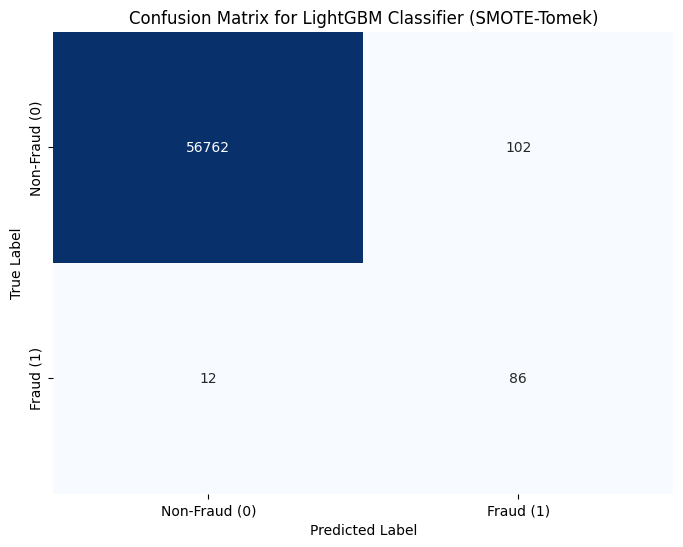

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the SMOTE-Tomek model
cm_smtom = confusion_matrix(y_test_orig_smtom, y_pred_smtom)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_smtom, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LightGBM Classifier (SMOTE-Tomek)')
plt.show()

##### Feature Importance (LGBM with SMOTE-Tomek)

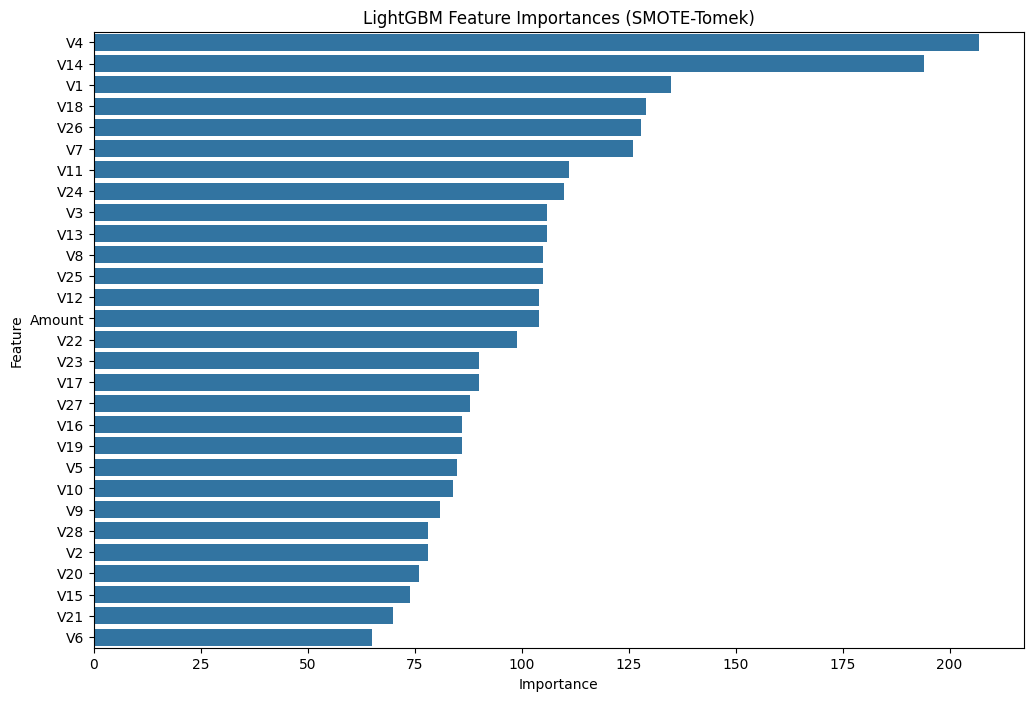

In [8]:
# Get feature importances from the LGBM model trained with SMOTE-Tomek
feature_importances_smtom = pd.DataFrame({
    'feature': X_original.columns, # Use original column names for features
    'importance': lgbm_clf_smtom.feature_importances_
}).sort_values(by='importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_smtom)
plt.title('LightGBM Feature Importances (SMOTE-Tomek)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Cost-sensitive learning

Cost-sensitive learning is an approach where different misclassification errors are assigned different costs. In the context of imbalanced datasets, it's particularly useful when the cost of misclassifying the minority class (e.g., a fraudulent transaction) is significantly higher than misclassifying the majority class (e.g., a legitimate transaction).

Here are the different ways to implement cost-sensitive learning to handle unbalanced datasets:

## Algorithm-Level Approaches
### Modifying the Loss Function
Some algorithms allow you to directly modify their loss functions to incorporate misclassification costs. `For instance, in LightGBM, you can use the is_unbalance=True parameter or set scale_pos_weight to assign a larger weight to the minority class`. This effectively penalizes false negatives (missing a fraud) more heavily than false positives (flagging a legitimate transaction as fraud).
### Cost-Sensitive Decision Trees/Random Forests
Some tree-based algorithms can be adapted to consider misclassification costs when splitting nodes or making predictions. `For example, a split might be preferred if it reduces high-cost errors, even if it doesn't lead to the highest overall accuracy`.
### Support Vector Machines (SVMs) with Class Weights
`In SVMs, you can use the class_weight parameter (e.g., class_weight='balanced')` to assign higher penalties to errors on the minority class during optimization.


## Data-Level Approaches with Cost Awareness
### Weighted Sampling
Instead of just oversampling or undersampling to balance the counts, you can sample instances based on their misclassification costs. `For example, minority class samples with high misclassification costs might be oversampled more aggressively`.


## Post-Processing Approaches
### Adjusting Decision Thresholds
Even with a standard model trained on an imbalanced dataset, you can adjust the decision threshold for classification. `If you have predicted probabilities, instead of using a default threshold of 0.5, you can lower it to increase the recall of the minority class (at the potential expense of precision) if catching every fraudulent transaction is paramount`. The optimal threshold can be determined by minimizing a cost matrix.
Key Benefit:

Cost-sensitive learning directly optimizes for the business objective by acknowledging that not all errors are equal. This is crucial in domains like fraud detection, medical diagnosis, or rare event prediction where the consequences of a false negative can be severe.

### Algorithmic Approch (Modifying Loss Function Using `scale_pos_weight`)

To apply cost-sensitive learning in LightGBM using the `scale_pos_weight` parameter, we need to calculate the ratio of the number of negative samples (majority class) to the number of positive samples (minority class) in the training data.

This parameter is crucial when dealing with imbalanced datasets like fraud detection, as it helps the model give more importance to the minority class during training.

In [9]:
# Check if y_train_original is defined, if not, re-prepare the data
if 'y_train_original' not in locals():
    print("y_train_original not found. Re-preparing original imbalanced data.")
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    import pandas as pd # Ensure pandas is imported for DataFrame operations

    # Assuming 'df' is already loaded from previous cells
    if 'df' not in locals():
        raise NameError("DataFrame 'df' not found. Please ensure the dataset loading cell is executed.")

    X_original = df.drop(['Class', 'Time'], axis=1)
    y_original = df['Class']

    # Split Original Data into Training and Test Sets
    X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X_original, y_original,
                                                                                            test_size=0.2, random_state=42,
                                                                                            stratify=y_original)

    # Scale the Training and Test Data (optional for scale_pos_weight calc, but good practice)
    scaler_smote = StandardScaler()
    X_train_original_scaled = scaler_smote.fit_transform(X_train_original)
    X_test_original_scaled = scaler_smote.transform(X_test_original)

    # Convert back to DataFrame to retain column names for consistency
    X_train_original_scaled = pd.DataFrame(X_train_original_scaled, columns=X_original.columns)
    X_test_original_scaled = pd.DataFrame(X_test_original_scaled, columns=X_original.columns)
    print("Original imbalanced data (X_original, y_original) and splits (X_train_original, y_train_original) re-prepared.")


# Get the count of each class in the original training set
count_class_0 = y_train_original.value_counts()[0]
count_class_1 = y_train_original.value_counts()[1]

# Calculate scale_pos_weight
scale_pos_weight = count_class_0 / count_class_1

print(f"Number of non-fraudulent transactions (class 0) in original training data: {count_class_0}")
print(f"Number of fraudulent transactions (class 1) in original training data: {count_class_1}")
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

y_train_original not found. Re-preparing original imbalanced data.
Original imbalanced data (X_original, y_original) and splits (X_train_original, y_train_original) re-prepared.
Number of non-fraudulent transactions (class 0) in original training data: 227451
Number of fraudulent transactions (class 1) in original training data: 394
Calculated scale_pos_weight: 577.29


#### Model Training and Evaluation with Cost-Sensitive Learning (LightGBM)

We will now train a new `LGBMClassifier` using the calculated `scale_pos_weight` to implement cost-sensitive learning. This parameter will give more importance to the minority class (fraudulent transactions) during training, aiming to reduce false negatives. We will train the model on the original scaled training data (`X_train_original_scaled`, `y_train_original`) and evaluate its performance on the original scaled test data (`X_test_original_scaled`, `y_test_original`).

In [10]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize the LightGBM Classifier with scale_pos_weight
lgbm_clf_cs = LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight)

# Train the model on the original scaled training data
print("Training LightGBM Classifier with Cost-Sensitive learning...")
lgbm_clf_cs.fit(X_train_original_scaled, y_train_original)
print("LightGBM Classifier with Cost-Sensitive learning trained successfully.")

# Make predictions on the scaled original test data
y_pred_cs = lgbm_clf_cs.predict(X_test_original_scaled)
y_pred_proba_cs = lgbm_clf_cs.predict_proba(X_test_original_scaled)[:, 1] # Probability of the positive class (fraud)

# Calculate evaluation metrics
accuracy_cs = accuracy_score(y_test_original, y_pred_cs)
precision_cs = precision_score(y_test_original, y_pred_cs)
recall_cs = recall_score(y_test_original, y_pred_cs)
f1_cs = f1_score(y_test_original, y_pred_cs)
roc_auc_cs = roc_auc_score(y_test_original, y_pred_proba_cs)

print(f"\nModel Performance on Original Test Set (LGBM with Cost-Sensitive Training):")
print(f"  Accuracy: {accuracy_cs:.4f}")
print(f"  Precision: {precision_cs:.4f}")
print(f"  Recall: {recall_cs:.4f}")
print(f"  F1-Score: {f1_cs:.4f}")
print(f"  ROC AUC Score: {roc_auc_cs:.4f}")

Training LightGBM Classifier with Cost-Sensitive learning...
[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.072793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

#### About Warning
In the context of `scale_pos_weight`:

When scale_pos_weight is very high (as it is here, 577.29), the model heavily penalizes misclassifying the minority class. This can make the model very aggressive in trying to correctly classify the few positive samples. `Sometimes, this can lead to very shallow or simple trees, where the model quickly finds a few splits that isolate the minority class samples, and then struggles to find further meaningful splits that continue to improve the weighted metric without significantly hurting the majority class (or vice versa)`. It might be that the model has reached a point where further splits lead to overfitting or are deemed not beneficial under the heavily weighted loss.

Essentially, the model is telling us it couldn't find more structural improvements to the trees given the data and parameters, particularly with the strong emphasis on the minority class.

#### Visualization of LightGBM Model Performance with Cost-Sensitive Learning

Let's visualize the performance of the `LGBMClassifier` trained with `scale_pos_weight`. We'll generate a Confusion Matrix, Feature Importance plot, and an ROC Curve, using the predictions from this trained model on the original (unseen) test set.

##### Confusion Matrix (LGBM with Cost-Sensitive Learning)

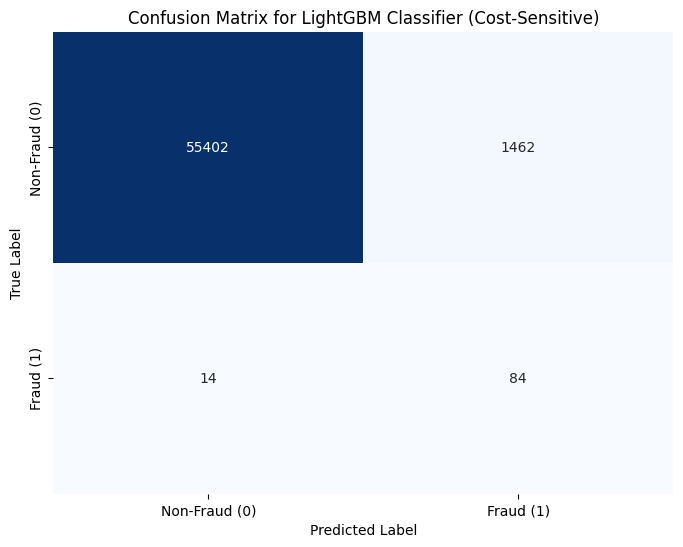

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the cost-sensitive model
cm_cs = confusion_matrix(y_test_original, y_pred_cs)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cs, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LightGBM Classifier (Cost-Sensitive)')
plt.show()

##### Feature Importance (LGBM with Cost-Sensitive Learning)

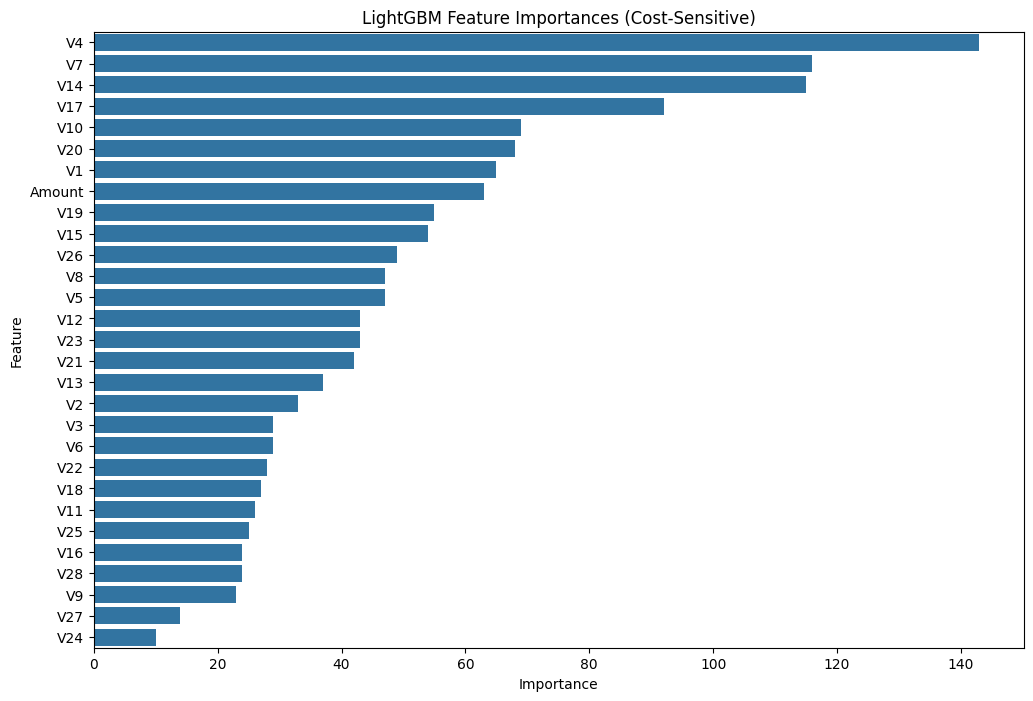

In [ ]:
# Get feature importances from the LGBM model trained with cost-sensitive learning
feature_importances_cs = pd.DataFrame({
    'feature': X_original.columns, # Use original column names for features
    'importance': lgbm_clf_cs.feature_importances_
}).sort_values(by='importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_cs)
plt.title('LightGBM Feature Importances (Cost-Sensitive)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

##### Area Under the Receiver Operating Characteristic Curve (AUC-ROC) (LGBM with Cost-Sensitive Learning)

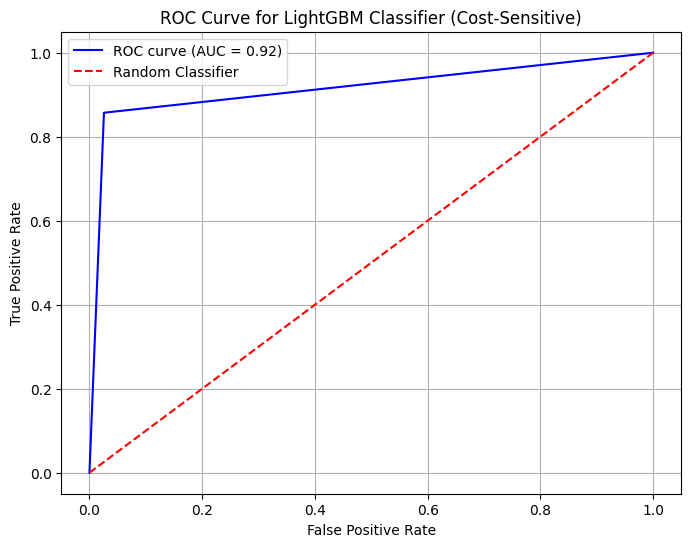

In [ ]:
from sklearn.metrics import roc_curve

# Calculate ROC curve points for the cost-sensitive model
fpr_cs, tpr_cs, thresholds_cs = roc_curve(y_test_original, y_pred_proba_cs)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_cs, tpr_cs, color='blue', label=f'ROC curve (AUC = {roc_auc_cs:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LightGBM Classifier (Cost-Sensitive)')
plt.legend()
plt.grid(True)
plt.show()

### Weighted Sampling (Data-Level Approaches with Cost Awareness)

Weighted sampling, in this context, refers to a data-level technique where we adjust the class distribution in the training set to reflect the *cost* of misclassification, rather than simply aiming for a perfectly balanced 1:1 ratio. This is achieved by oversampling the minority class and/or undersampling the majority class to specific, pre-determined counts or ratios.

Here, we will demonstrate this by targeting a specific number of samples for both the minority and majority classes in our training data using `RandomOverSampler` and `RandomUnderSampler`. This allows for a granular control over the class distribution, allowing us to explicitly 'weight' the importance of the minority class by increasing its presence, but perhaps not to the extent of making it equal to the entire majority class.

For example, we might decide to:
*   Oversample the minority class (fraudulent transactions) to `X` samples.
*   Undersample the majority class (non-fraudulent transactions) to `Y` samples.

This creates a custom, cost-aware class distribution for training.

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- 1. Prepare Original Imbalanced Data (if not already prepared) ---
# This block ensures X_original, y_original, and their scaled splits are available.
# It reuses the logic from previous sections to ensure consistency and robustness.

# Re-define features (X_original) and target (y_original) from the original full dataframe (df)
if 'X_original' not in locals() or 'y_original' not in locals() or 'X_train_original_scaled' not in locals():
    print("Re-preparing original imbalanced data and splits...")
    if 'df' not in locals():
        raise NameError("DataFrame 'df' not found. Please ensure the dataset loading cell is executed.")

    X_original = df.drop(['Class', 'Time'], axis=1)
    y_original = df['Class']

    X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
        X_original, y_original, test_size=0.2, random_state=42, stratify=y_original)

    scaler_ws = StandardScaler()
    X_train_original_scaled = pd.DataFrame(scaler_ws.fit_transform(X_train_original), columns=X_original.columns)
    X_test_original_scaled = pd.DataFrame(scaler_ws.transform(X_test_original), columns=X_original.columns)
    print("Original imbalanced data and scaled splits prepared.")

print(f"Original imbalanced dataset shape: X={X_original.shape}, y={y_original.shape}")
print("Original class distribution (in full dataset):")
display(y_original.value_counts())

print(f"\nShape of original scaled training data: X_train_original_scaled={X_train_original_scaled.shape}, y_train_original={y_train_original.shape}")
print("Class distribution in original training data:")
display(y_train_original.value_counts())

# --- 2. Define Weighted Sampling Strategy ---
# Let's define target counts for our weighted sampling.
# For demonstration, we'll aim to significantly increase the minority class
# and reduce the majority class, but not necessarily to a 1:1 ratio.

# Current training set counts:
count_class_0_train = y_train_original.value_counts()[0]
count_class_1_train = y_train_original.value_counts()[1]

# Example target: Oversample minority to 10,000 samples, Undersample majority to 50,000 samples.
# These numbers are chosen for demonstration and can be adjusted based on domain knowledge/cost matrix.
target_minority_samples = 10000
target_majority_samples = 50000

# Ensure target counts are reasonable
if target_minority_samples < count_class_1_train:
    target_minority_samples = count_class_1_train # Don't undersample minority by accident

if target_majority_samples > count_class_0_train:
    target_majority_samples = count_class_0_train # Don't oversample majority by accident if it's already less

# Create a dictionary for sampling strategy
# RandomOverSampler will increase the minority class to target_minority_samples
# RandomUnderSampler will reduce the majority class to target_majority_samples

oversampling_strategy = {1: target_minority_samples}
undersampling_strategy = {0: target_majority_samples}

# Initialize samplers
ros_ws = RandomOverSampler(sampling_strategy=oversampling_strategy, random_state=42)
rus_ws = RandomUnderSampler(sampling_strategy=undersampling_strategy, random_state=42)

# Create a pipeline for oversampling and then undersampling
pipeline_ws = Pipeline([('oversample', ros_ws), ('undersample', rus_ws)])

# --- 3. Apply Weighted Sampling to the Training Data ---
print(f"\nApplying Weighted Sampling (target: Minority={target_minority_samples}, Majority={target_majority_samples})...")
X_train_ws, y_train_ws = pipeline_ws.fit_resample(X_train_original_scaled, y_train_original)

print(f"Shape after Weighted Sampling on training data: X_train_ws={X_train_ws.shape}, y_train_ws={y_train_ws.shape}")
print("Class distribution after Weighted Sampling:")
display(y_train_ws.value_counts())

Original imbalanced dataset shape: X=(284807, 29), y=(284807,)
Original class distribution (in full dataset):


,count
Class,
0,284315
1,492



Shape of original scaled training data: X_train_original_scaled=(227845, 29), y_train_original=(227845,)
Class distribution in original training data:


,count
Class,
0,227451
1,394



Applying Weighted Sampling (target: Minority=10000, Majority=50000)...
Shape after Weighted Sampling on training data: X_train_ws=(60000, 29), y_train_ws=(60000,)
Class distribution after Weighted Sampling:


,count
Class,
0,50000
1,10000


#### Have We Randomly Chosen 10K / 50K Values
In a real-world scenario, these target sample counts would typically be determined based on:

`1. Domain Knowledge:`
Understanding the specific costs associated with false positives (e.g., investigating a legitimate transaction) and false negatives (e.g., missing a fraudulent transaction).

`2. Cost Matrix:`
If you have a predefined cost matrix that quantifies these misclassification costs, you would use it to find the optimal class ratio that minimizes the total cost.

`3. Experimentation/Hyperparameter Tuning:`
You might experiment with different target ratios and evaluate the model's performance (especially metrics like recall and precision relevant to your specific business objective) on a validation set to find the most effective balance for your problem.

So, while the numbers used in the code serve to illustrate the technique, they represent values that would be carefully chosen in a practical application based on performance and business impact considerations.

#### Model Training and Evaluation with Weighted Sampled Data (LightGBM)

With our training data transformed using weighted sampling, we can now train a new `LGBMClassifier` and evaluate its performance on the original (unseen) test set.

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize the LightGBM Classifier for weighted sampled data
lgbm_clf_ws = LGBMClassifier(random_state=42)

# Train the model on weighted-resampled training data
print("Training LightGBM Classifier with Weighted Sampled data...")
lgbm_clf_ws.fit(X_train_ws, y_train_ws)
print("LightGBM Classifier with Weighted Sampled data trained successfully.")

# Make predictions on the scaled original test data
y_pred_ws = lgbm_clf_ws.predict(X_test_original_scaled)
y_pred_proba_ws = lgbm_clf_ws.predict_proba(X_test_original_scaled)[:, 1] # Probability of the positive class (fraud)

# Calculate evaluation metrics
accuracy_ws = accuracy_score(y_test_original, y_pred_ws)
precision_ws = precision_score(y_test_original, y_pred_ws)
recall_ws = recall_score(y_test_original, y_pred_ws)
f1_ws = f1_score(y_test_original, y_pred_ws)
roc_auc_ws = roc_auc_score(y_test_original, y_pred_proba_ws)

print(f"\nModel Performance on Original Test Set (LGBM with Weighted Sampling Training):")
print(f"  Accuracy: {accuracy_ws:.4f}")
print(f"  Precision: {precision_ws:.4f}")
print(f"  Recall: {recall_ws:.4f}")
print(f"  F1-Score: {f1_ws:.4f}")
print(f"  ROC AUC Score: {roc_auc_ws:.4f}")

Training LightGBM Classifier with Weighted Sampled data...
[LightGBM] [Info] Number of positive: 10000, number of negative: 50000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166667 -> initscore=-1.609438
[LightGBM] [Info] Start training from score -1.609438
LightGBM Classifier with Weighted Sampled data trained successfully.

Model Performance on Original Test Set (LGBM with Weighted Sampling Training):
  Accuracy: 0.9992
  Precision: 0.7143
  Recall: 0.8673
  F1-Score: 0.7834
  ROC AUC Score: 0.9823


#### Visualization of LightGBM Model Performance with Weighted Sampled Data

Now let's visualize the performance of the `LGBMClassifier` trained on weighted-sampled data. We'll generate a Confusion Matrix, Feature Importance plot, and an ROC Curve, using the predictions from this trained model on the original (unseen) test set.

##### Confusion Matrix (LGBM with Weighted Sampling)

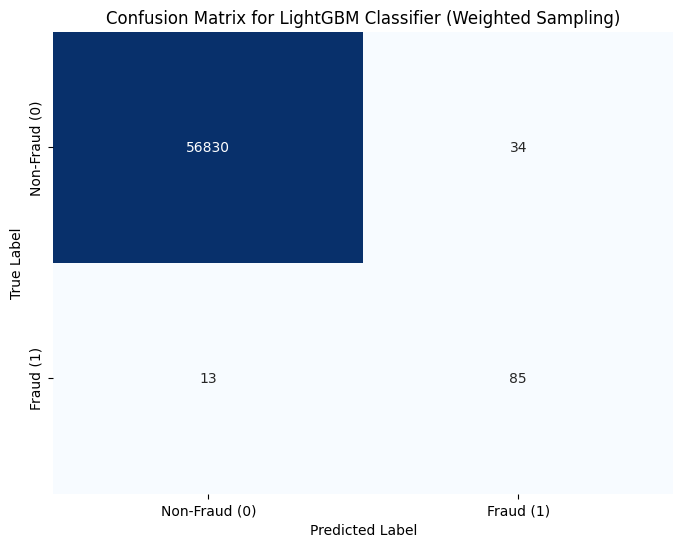

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the weighted sampled model
cm_ws = confusion_matrix(y_test_original, y_pred_ws)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ws, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LightGBM Classifier (Weighted Sampling)')
plt.show()

##### Feature Importance (LGBM with Weighted Sampling)

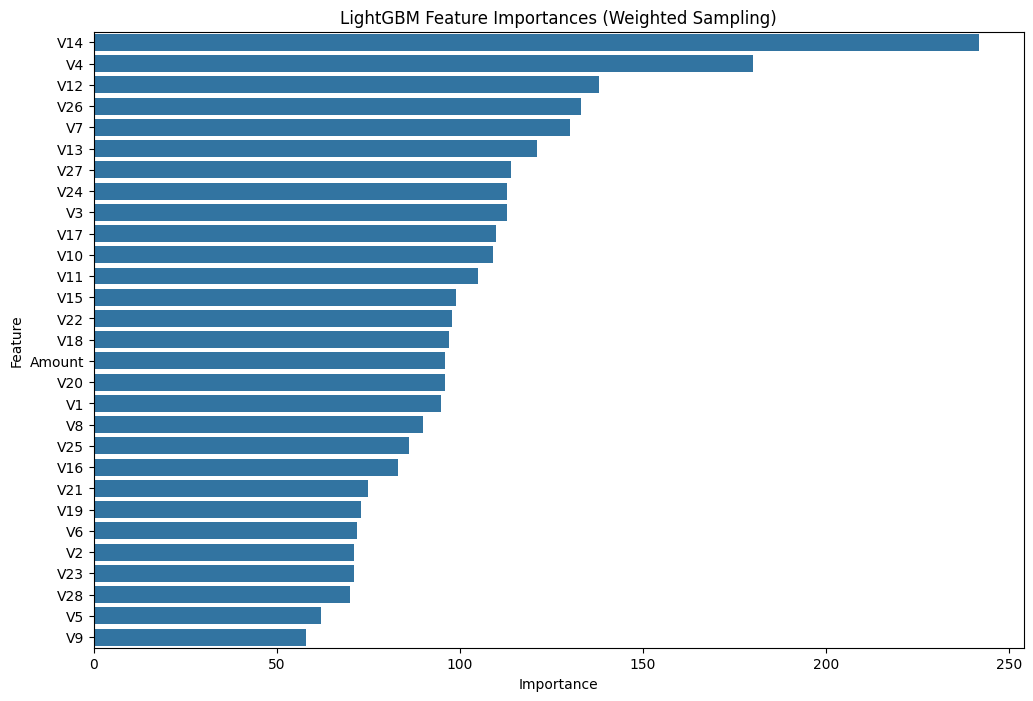

In [ ]:
# Get feature importances from the LGBM model trained with weighted sampling
feature_importances_ws = pd.DataFrame({
    'feature': X_original.columns, # Use original column names for features
    'importance': lgbm_clf_ws.feature_importances_
}).sort_values(by='importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_ws)
plt.title('LightGBM Feature Importances (Weighted Sampling)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

##### Area Under the Receiver Operating Characteristic Curve (AUC-ROC) (LGBM with Weighted Sampling)

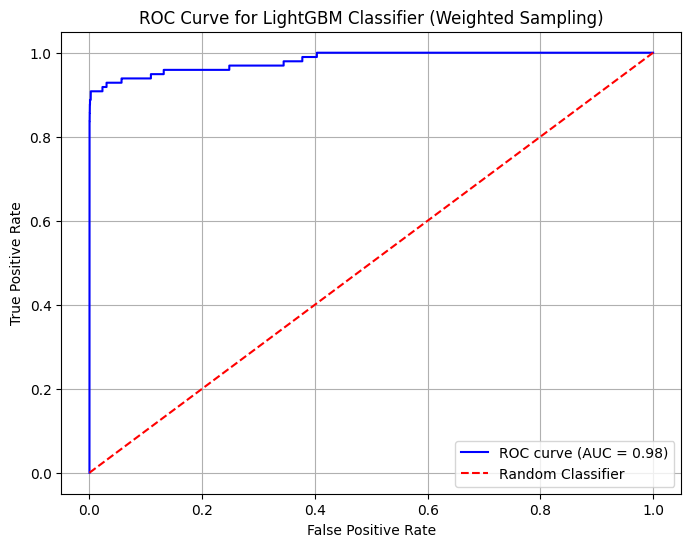

In [ ]:
from sklearn.metrics import roc_curve

# Calculate ROC curve points for the weighted sampling model
fpr_ws, tpr_ws, thresholds_ws = roc_curve(y_test_original, y_pred_proba_ws)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_ws, tpr_ws, color='blue', label=f'ROC curve (AUC = {roc_auc_ws:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LightGBM Classifier (Weighted Sampling)')
plt.legend()
plt.grid(True)
plt.show()

### Post-Processing: Adjusting Decision Thresholds

Adjusting the decision threshold is a crucial post-processing step for classification models, especially when dealing with imbalanced datasets or when different types of misclassifications have varying costs.

By default, a binary classifier typically uses a threshold of 0.5: if the predicted probability of the positive class is >= 0.5, it's classified as positive (e.g., fraud), otherwise as negative (e.g., non-fraud).

However, in fraud detection, incorrectly classifying a fraudulent transaction as legitimate (False Negative) can be much more costly than incorrectly flagging a legitimate transaction as fraudulent (False Positive). In such cases, we might want to lower the threshold to increase the recall (catch more fraud) even if it means a slight decrease in precision (more false alarms).

We will use the **Precision-Recall curve** to visualize the trade-off between precision and recall across different thresholds and select an optimal threshold based on a chosen metric (like F1-score or specific business requirements).

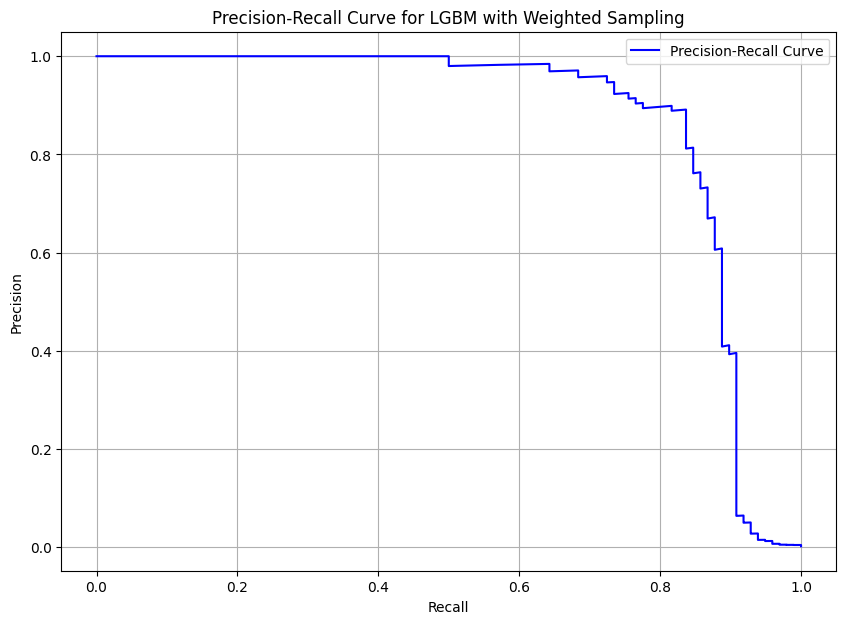

Optimal Threshold (maximizing F1-score): 0.9848

Model Performance on Original Test Set (LGBM with Weighted Sampling & Optimal Threshold):
  Accuracy: 0.9995
  Precision: 0.8913
  Recall: 0.8367
  F1-Score: 0.8632
  ROC AUC Score: 0.9823


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Get precision, recall, and thresholds from the weighted sampling model
precision_ws_curve, recall_ws_curve, thresholds_ws_curve = precision_recall_curve(y_test_original, y_pred_proba_ws)

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 7))
plt.plot(recall_ws_curve, precision_ws_curve, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for LGBM with Weighted Sampling')
plt.grid(True)
plt.legend()
plt.show()

# Find the optimal threshold that maximizes the F1-score
f1_scores = 2 * (precision_ws_curve * recall_ws_curve) / (precision_ws_curve + recall_ws_curve)
optimal_threshold_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_ws_curve[optimal_threshold_idx]

print(f"Optimal Threshold (maximizing F1-score): {optimal_threshold:.4f}")

# Re-evaluate with the optimal threshold
y_pred_optimal_threshold = (y_pred_proba_ws >= optimal_threshold).astype(int)

accuracy_opt = accuracy_score(y_test_original, y_pred_optimal_threshold)
precision_opt = precision_score(y_test_original, y_pred_optimal_threshold)
recall_opt = recall_score(y_test_original, y_pred_optimal_threshold)
f1_opt = f1_score(y_test_original, y_pred_optimal_threshold)
roc_auc_opt = roc_auc_score(y_test_original, y_pred_proba_ws) # ROC AUC remains the same as it's threshold-independent

print(f"\nModel Performance on Original Test Set (LGBM with Weighted Sampling & Optimal Threshold):")
print(f"  Accuracy: {accuracy_opt:.4f}")
print(f"  Precision: {precision_opt:.4f}")
print(f"  Recall: {recall_opt:.4f}")
print(f"  F1-Score: {f1_opt:.4f}")
print(f"  ROC AUC Score: {roc_auc_opt:.4f}")

#### Confusion Matrix (LGBM with Weighted Sampling - Optimal Threshold)

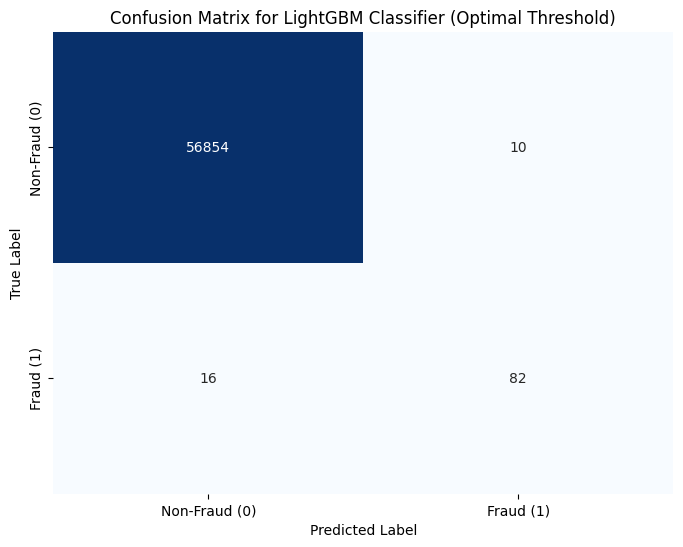

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for the weighted sampled model with optimal threshold
cm_opt = confusion_matrix(y_test_original, y_pred_optimal_threshold)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LightGBM Classifier (Optimal Threshold)')
plt.show()